# 11. Feedback models

## Numerical experiments - Week 38/2025

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

The collection of models can be further expanded by taking into account mechanisms of simultaneous two-sided influence by the inducer and the inhibitor. First, this can be used to correct the flaw in the assumption of an inducer-controlled inhibitor permeability. If the inducer causes a change in the cell wall porosity, then this would affect its own permeation with an equivalent factor. Second, feedback loops between the two actors can be explored, resulting in models with:
- inhibitor-dependent induction strength AND inducer-dependent inhibitor permeability;
- inhibitor-dependent induction strength AND inducer-dependent inhibitor threshold;
- inhibitor-dependent induction threshold AND inducer-dependent inhibitor permeability;
- inhibitor-dependent induction threshold AND inducer-dependent inhibitor threshold.

Each of these compound interaction can be combined with either a single-factor (inducer- or inhibitor-defined) germination or a two-factor germination, resulting in a total of 12 additional models.

## Prerequisite libraries

In [1]:
using PyPlot
using DifferentialEquations
using Statistics
using Distributions
using QuasiMonteCarlo

include("../src/conversions.jl")
include("../src/diffusion.jl")
include("../src/setup.jl")
include("../src/plotting.jl")
include("../src/analysis.jl")
include("../src/datautils.jl")
include("../src/germstats.jl")

using .Conversions
using .Diffusion
using .Setup
using .Plotting
using .Analysis
using .DataUtils
using .GermStats

## 1. Inducer-dependent permeability - revision

### 1.1. Mathematical formulation and integration

The change of inhibitor concentration in the spore over time is given by the ODE

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{I}}}}{d{t}}=-\left(\frac{(1+s) P_s^{\textrm{I}}A}{V_s}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

where the signal strength $s$ modulates the inhibitor permeation through the cell wall. This happens via a linear shift from a base permeability value, since it is assumed that inhibitor molecules can still escape the cell wall in the complete absence of induction.

The outside concentration changes like

$$
\begin{equation}
\frac{d{c_{\textrm{out}}^{\textrm{I}}}}{d{t}}=\left(\frac{(1+s) P_s^{\textrm{I}}A}{V_{\textrm{free}}}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

where $V_{\textrm{free}}=V_{\textrm{des}}-V_s$ is the volume unoccupied by a spore in the equally designated space per spore.

The concentration drop of inducer across the outer cell wall, on the other hand, follows the formula

$$
\begin{equation}
\frac{d{\Delta c^{\textrm{C}}}}{d{t}}=-\left(\frac{(1+s)P_s^{\textrm{C}}A}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}\right],
\end{equation}
$$

Where $V_{\textrm{ps}}$ denotes the volume of the polysaccharide layer (inner cell wall). The permeability is modulated via the cell wall structure, so the scaling factor $s$ is used here as well. Since $\Delta c^{\textrm{C}}=c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}$ and $c_{\textrm{out}}^{\textrm{C}}{(t)}=c_0^{\textrm{C}}$ is a constant, this equates to

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}=-\left(\frac{(1+s)P_s^{\textrm{C}}A}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

As a reminder,

$$
\begin{equation}
    s{(c_{\textrm{in}}^{\textrm{C}})}=s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}},
\end{equation}
$$

where $s_{\textrm{max}}$ scales the concentration function to its appropriate magnitude of effect on the permeability. Therefore,

$$
\begin{equation}
    1+s{(c_{\textrm{in}}^{\textrm{C}})}=\frac{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}})}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}.
\end{equation}
$$

Thus, the following system of coupled ODEs needs to be solved:

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{I}}A}{V_s(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{I}}A}{\left(1/\rho_s-V_s\right)(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{C}}A}{V_{\textrm{ps}}(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

Factoring out $g(c_{\textrm{in}}^{\textrm{C}})=\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ A}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}$,

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

The integration of these ODEs is demonstrated below. As a check, the number of inhibitor molecules is tracked by referring the concentrations to the respective volumes.

  0.882553 seconds (2.54 M allocations: 174.026 MiB, 99.68% compilation time)
Variance of inhibitor molecule count: 5.477116046956792e-29


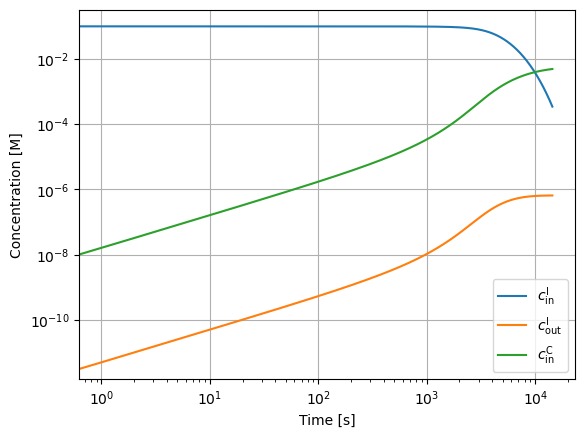

In [46]:
matplotlib.pyplot.close()

R = 2.5
A, Vₛ = compute_spore_area_and_volume_from_dia(2R)
K_cs = 0.001 # M
s_max = 0.1
ρₛ = inverse_mL_to_cubic_um(1e5) # spores/μm^3
V_out = 1/ρₛ - Vₛ
d_hp = 0.01
d_ps = 0.2
V_ps = 0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3)
Pₛ_I = 5e-4 # μm/s
Pₛ_C = 1e-5 # μm/s
c_ex_C = 0.00556 # M
c₀_I = 0.1 # M

# ODE function
function ode!(du, u, p, t)
    cinI, coutI, cinC = u

    g = (p.K_cs + cinC * (1 + p.s_max) * p.A) / (p.K_cs + cinC)
    rateI = g * p.Pₛ_I
    rateC = g * p.Pₛ_C

    du[1] = -(rateI / p.Vₛ) * (cinI - coutI)
    du[2] = (rateI / p.V_out) * (cinI - coutI)
    du[3] = -(rateC / p.V_ps) * (cinC - c_ex_C)
end

# Initial condition
u0 = [c₀_I, 0.0, 0.0] # [cinI, coutI, cinC]
p = (A=A, Vₛ=Vₛ, V_out=V_out, V_ps=V_ps, Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)
tspan = (0.0, 14400.0)

# Integration
save_times = 0:1:14400
@time begin
    prob = ODEProblem(ode!, u0, tspan, p)
    sol = solve(prob, Tsit5(); saveat=save_times)
end
# sol = solve(prob, Rodas5())

sol_mat = reduce(hcat, sol.u)

# Molecules check
Nin = Vₛ .* sol_mat[1, :]
Nout = V_out .* sol_mat[2, :]
Ntot = Nin .+ Nout
println("Variance of inhibitor molecule count: ", var(Ntot))

# Plot concentration courses
fig, ax = subplots()
ax.loglog(sol.t, sol_mat[1, :], label=L"c_{\text{in}}^\text{I}")
ax.loglog(sol.t, sol_mat[2, :], label=L"c_{\text{out}}^\text{I}")
ax.loglog(sol.t, sol_mat[3, :], label=L"c_{\text{in}}^\text{C}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Concentration [M]")
ax.grid(true)
ax.legend()
gcf()

### 1.2. Estimation of the germination probability

Due to the non-linearity in the ODEs, there is no closed-form analytical solution and the estimation of a germination probability becomes difficult. Some simplifications can be made if it is found that the ODE mapping is approximately linear when the spore radius $R$ and the initial inhibitor concentration $c_0^\textrm{I}$ vary randomly.

A straightforward test for this involves Monte Carlo sampling of the two varying parameters under observation of the output linearity.

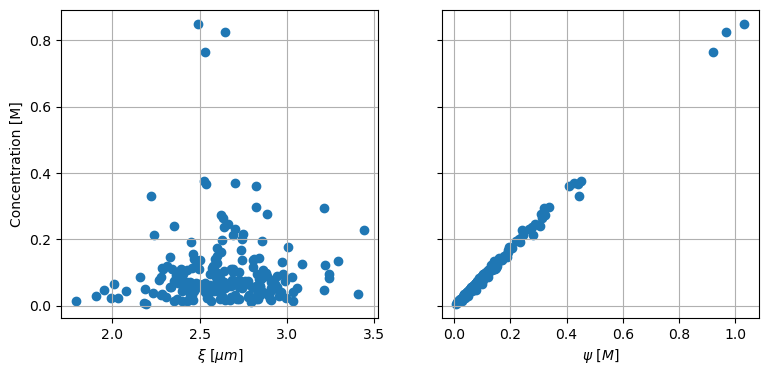

In [47]:
matplotlib.pyplot.close()

function c_in_inducer_dependent_permeability(t, ρₛ, R, d_hp, d_ps, c₀_I, c₀_C, Pₛ_I, Pₛ_C, s_max, K_cs)
    """
    Compute internal inhibitor concentration.
    inputs:
        t - time for evaluation in seconds
        ρₛ - spore density in spores/mL
        R - spore density in μm
        d_hp - hydrophobin layer thickness in μm
        d_ps - polysaccharide layer thickness in μm
        c₀_I - initial internal inhibitor concentration in M
        c₀_I - initial external inducer concentration in M
        Pₛ_I - inhibitor permeation constant in μm/s
        Pₛ_C - inducer permeation constant in μm/s
        s_max - maximum inductive signal strength
        K_cs - half-saturation constant for the carbon source in M
    """

    A, Vₛ = compute_spore_area_and_volume_from_dia(2*R)
    ρₛ = inverse_mL_to_cubic_um(ρₛ) # spores/mL
    V_out = 1/ρₛ - Vₛ
    V_ps = 0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3)

    # ODE function
    function ode!(du, u, p, t)
        cinI, coutI, cinC = u

        g = (K_cs + cinC * (1 + s_max) * A) / (K_cs + cinC)
        rateI = g * Pₛ_I
        rateC = g * Pₛ_C

        du[1] = -(rateI / Vₛ) * (cinI - coutI)
        du[2] = (rateI / V_out) * (cinI - coutI)
        du[3] = -(rateC / V_ps) * (cinC - c_ex_C)
    end

    u0 = [c₀_I, 0.0, 0.0]
    tspan = (0.0, t)

    prob = ODEProblem(ode!, u0, tspan)
    sol = solve(prob, Tsit5())

    return sol.u[end][1]
end

# Random samples
n_samples = 200

μ_ξ = 2.65
σ_ξ = 0.3
μ_ξ_log = log(μ_ξ^2 / sqrt(σ_ξ^2 + μ_ξ^2))
σ_ξ_log = sqrt(log(σ_ξ^2 / μ_ξ^2 + 1))
dist_ξ = LogNormal(μ_ξ_log, σ_ξ_log)
samples_ξ = rand(dist_ξ, n_samples)

μ_ψ = 0.1
δ_ψ = 0.1
μ_ψ_log = log(μ_ψ^2 / sqrt(δ_ψ^2 + μ_ψ^2))
δ_ψ_log = sqrt(log(δ_ψ^2 / μ_ψ^2 + 1))
dist_ψ = LogNormal(μ_ψ_log, δ_ψ_log)
samples_ψ = rand(dist_ψ, n_samples)

t_max = 14400
samples_c_in = zeros(n_samples)
for n in 1:n_samples
    samples_c_in[n] = c_in_inducer_dependent_permeability(t_max, ρₛ, samples_ξ[n], samples_ψ[n], c_ex_C, Pₛ_I, Pₛ_C, s_max, K_cs)
end

# Plot samples
fig, ax = subplots(1, 2, figsize=(9, 4), sharey=true)
ax[1].grid(true)
ax[2].grid(true)
ax[1].scatter(samples_ξ, samples_c_in)
ax[2].scatter(samples_ψ, samples_c_in)
ax[1].set_xlabel(L"\xi \ [\mu m]")
ax[1].set_ylabel("Concentration [M]")
ax[2].set_xlabel(L"\psi \ [M]")
# ax.grid(true)
gcf()

The scatter plots demonstrate clearly that the ODE mapping is quite linear in the random initial concentration $\psi$, but not in $\xi$. Therefore, a linear approximation is not feasible and Monte Carlo sampling appears the best way to integrate the germination probabilities. The case observed below is an inhibitor-dependent germination with an inducer-dependent cell wall permeability. Hence, $\gamma$ is added as a random parameter. It is investigated at what sample size the solution converges to a stable value by measuring the variance of 50 runs per sample size.

The sampling is performed using shuffled Sobol sequences.

In [48]:
# Fixed parameters
K_cs = 0.001 # M
s_max = 0.1
ρₛ = inverse_mL_to_cubic_um(1e5) # spores/μm^3
Pₛ_I = 5e-4 # μm/s
Pₛ_C = 1e-5 # μm/s
c_ex_C = 0.00556 # M
d_hp = 0.01 # μm
d_ps = 0.2 # μm

t_query = 14400
n_sample_range = 2 .^ (3:15)
n_runs = 50

μ_ξ = 2.65
σ_ξ = 0.3
μ_ψ = 0.1
δ_ψ = 0.1
μ_γ = 1e-2
δ_γ = 1e-3

# Template problem
dummyA, dummyV = compute_spore_area_and_volume_from_dia(2*μ_ξ)
p_template = (A=dummyA, Vₛ=dummyV, V_out=1.0/ρₛ - dummyV, V_ps=0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3),
              Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)
u0_template = [μ_ψ, 0.0, 0.0]
tspan = (0.0, t_query)
prob = ODEProblem(ode!, u0_template, tspan, p_template)

pct_means = zeros(length(n_sample_range))
pct_vars = zeros(length(n_sample_range))

for (i, n_samples) in enumerate(n_sample_range)

    println("Running sample size ", n_samples)
    
    pcts = zeros(n_runs)

    for j in 1:n_runs

        # Random samples
        sobol_pts = QuasiMonteCarlo.sample(n_samples, 3, SobolSample(R = OwenScramble(base = 2, pad = 2+i)))
        
        μ_ξ_log = log(μ_ξ^2 / sqrt(σ_ξ^2 + μ_ξ^2))
        σ_ξ_log = sqrt(log(σ_ξ^2 / μ_ξ^2 + 1))
        dist_ξ = LogNormal(μ_ξ_log, σ_ξ_log)
        samples_ξ = quantile(dist_ξ, sobol_pts[1,:])

        μ_ψ_log = log(μ_ψ^2 / sqrt(δ_ψ^2 + μ_ψ^2))
        δ_ψ_log = sqrt(log(δ_ψ^2 / μ_ψ^2 + 1))
        dist_ψ = LogNormal(μ_ψ_log, δ_ψ_log)
        samples_ψ = quantile(dist_ψ, sobol_pts[2,:])

        μ_γ_log = log(μ_γ^2 / sqrt(δ_γ^2 + μ_γ^2))
        δ_γ_log = sqrt(log(δ_γ^2 / μ_γ^2 + 1))
        dist_γ = LogNormal(μ_γ_log, δ_γ_log)
        samples_γ = quantile(dist_γ, sobol_pts[3,:])

        function prob_func(prob, i, repeat)
            r = max(samples_ξ[i], 1e-9)
            A, Vₛ = compute_spore_area_and_volume_from_dia(2*r)
            V_des = 1.0 / ρₛ
            V_out = V_des - Vₛ
            V_ps = 0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3)
            new_p = (A=A, Vₛ=Vₛ, V_out=V_out, V_ps=V_ps,
                Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)

            new_u0 = [samples_ψ[i], 0.0, 0.0]
            remake(prob; u0 = new_u0, p = new_p)
        end

        # Run ODE ensembles
        ep = EnsembleProblem(prob; prob_func=prob_func)
        sols = solve(ep, Rodas5(), EnsembleThreads(), trajectories=n_samples, saveat=[t_query])

        # Evaluate fraction germinated
        c_inI_at_t = [ sols[i](t_query)[1] for i in 1:n_samples ]
        # println("Mean internal inhibitor concentration: ", mean(c_inI_at_t))
        germinated = c_inI_at_t .< samples_γ
        pct = 100 * mean(germinated)
        # println("Percent germinated: ", pct)

        pcts[j] = pct
    end

    pct_means[i] = mean(pcts)
    pct_vars[i] = var(pcts)
end

Running sample size 8
Running sample size 16
Running sample size 32
Running sample size 64
Running sample size 128
Running sample size 256
Running sample size 512
Running sample size 1024
Running sample size 2048
Running sample size 4096
Running sample size 8192
Running sample size 16384
Running sample size 32768


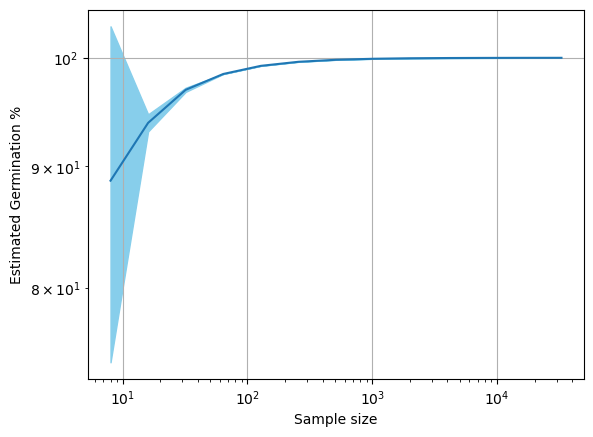

In [50]:
fig, ax = subplots()
ax.loglog(n_sample_range, pct_means)
ax.fill_between(n_sample_range, pct_means .- pct_vars, pct_means .+ pct_vars, color="skyblue")
ax.grid()
# ax.set_ylim(0, 10)
ax.set_xlabel("Sample size")
ax.set_ylabel("Estimated Germination %")
gcf()

It is thus visible that the variance converges at about $\mathcal{O}(10^3)$ samples, while the mean stabilizes at about $\mathcal{O}(10^4)$ samples. The lower sample size can be taken as sufficiently accurate for the practical purposes.

This enables a performance test of a parameter estimation procedure with the developed model.

In [2]:
model_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05,
    :Pₛ => 5e-4,
    :Pₛ_cs => 1e-5,
    :μ_γ => 1e-5,
    :σ_γ => 1e-6,
    :K_cs => 1.0,
    :s_max => 0.5,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01
)

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

compute_germination_response("feedback_inhibitor", times_eval, density_test, model_params)

UndefVarError: UndefVarError: `A` not defined